# Telecom Customer Churn Analysis

## 04: Multivariate Analysis and Customer Churn

### Objective

This notebook investigates how multiple customer characteristics, service usage patterns, and account factors interact in relation to customer churn.

The analysis focuses on:

- Examining how tenure and contract type interact in relation to churn
- Investigating how internet type, service subscriptions, and billing characteristics relate to churn when considered together
- Exploring how customer profile characteristics and tenure interact with churn
- Examining the relationship between offers, customer tenure, and churn
- Identifying combined patterns that may provide additional insight beyond individual bivariate relationships

This builds on the bivariate analysis by examining multiple variables together to better understand how customer characteristics and behaviors interact in relation to churn.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Load cleaned dataset from first notebook
churn_df = pd.read_parquet('../data/processed/telecom_customer_churn_clean.parquet')

In [3]:
# Set visualization settings
sns.set_theme(style='white', 
              context='notebook', 
              palette='deep')

plt.rcParams['figure.figsize'] = (5, 3)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 16
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelpad'] = 6
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

### Tenure, Contract, and Churn
- How does churn rate vary with tenure across different contract types?
- Are the tenure patterns of churn similar across contracts?

In [4]:
tenure_bins = list(range(1, 74, 12))
tenure_labels = [f'{tenure}-{tenure+11}' for tenure in tenure_bins[:-1]]

churn_df['Tenure Group'] = pd.cut(
    churn_df['Tenure in Months'],
    bins=tenure_bins,
    labels=tenure_labels,
    right=False
)

churn_rate_by_tenure_contract = (
    churn_df.groupby(['Tenure Group', 'Contract'])['Customer Status']
     .value_counts()[:, :, 'Churned'] /
    churn_df.groupby(['Tenure Group', 'Contract'])['Customer Status']
     .count()
    * 100
).unstack()

churn_rate_by_tenure_contract

Contract,Month-to-Month,One Year,Two Year
Tenure Group,,,
1-12,53.528489,8.904110,0.000000
13-24,40.524781,7.441860,0.000000
25-36,36.489607,7.462687,1.526718
37-48,37.588652,12.589928,1.980198
49-60,31.100478,13.496933,3.703704
61-72,27.586207,11.987382,3.090728


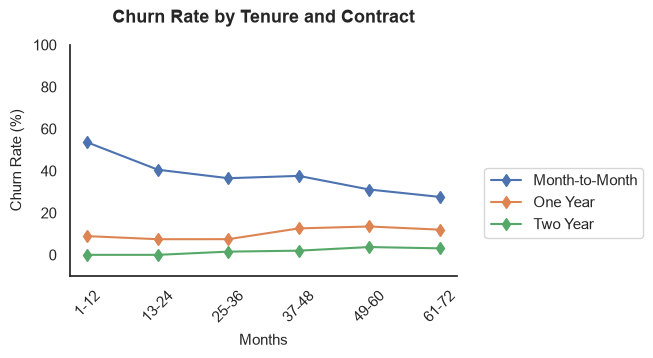

In [5]:
fig, ax = plt.subplots()

churn_rate_by_tenure_contract.plot.line(
ax=ax,
marker='d'
)

ax.set_title('Churn Rate by Tenure and Contract')
ax.set_xlabel('Months')
ax.set_ylabel('Churn Rate (%)')
ax.legend(loc='upper right', bbox_to_anchor=(1.5, 0.5));
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(-10, 100);


- Customers on month-to-month contracts consistently have higher churn rates than customers on one-year or two-year contracts across all tenure groups.
- Month-to-month customers have their highest churn rate during the first 12 months and generally declines as tenure increases.
- In comparison, churn remains much lower and relatively stable among customers on one-year and two-year contracts across tenure groups.

### Internet Services, Billing, and Churn
- Does the relationship between monthly charges and churn vary across internet types?

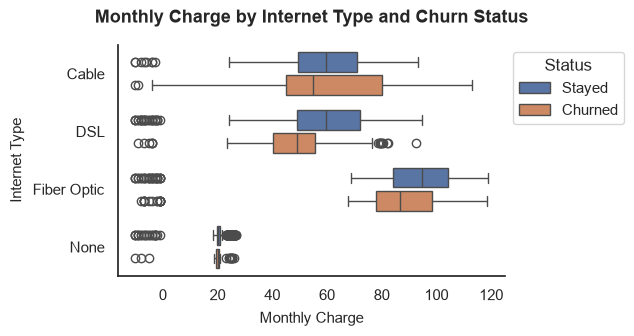

In [13]:
fig, ax = plt.subplots()

churn_df['Is Churned'] = churn_df['Customer Status'].apply(
    lambda x: True if x == 'Churned' else False
)

sns.boxplot(
    churn_df,
    x='Monthly Charge',
    y='Internet Type',
    hue='Is Churned',
    ax=ax,
    gap=0.15,
    legend=True
)


ax.set_title('Monthly Charge by Internet Type and Churn Status')
sns.move_legend(
    ax,
    loc='upper left',
    bbox_to_anchor=(1, 1),
    labels=['Stayed', 'Churned'],  # False maps to index 0, True to index 1
    title='Status'
)

- DSL (Lower charges associate with churn): Churned customers actually pay less (median around $49) than retained customers (median around $60). This indicates price hikes are not driving DSL cancellations; customers are more likely leaving basic, low-cost plans for faster alternatives.
- Fiber has the highest baseline cost of all services, where churners have a median charge around $87 compared to $95 for retained users. High overall bills define the category, but the churners tend to be on the slightly lower-to-mid tier of fiber pricing.
- None (No relationship): Both churned and retained customers are locked identically around $20–$25. Price variation has zero impact on churn for customers without internet.
- Cable (Wide dispersion drives churn): Retained customers stay within a predictable $49–$71 range, whereas churned customers spread broadly with an upper whisker stretching past $110. Expensive, highly bundled cable plans carry substantial churn risk.

### Additional Services, Contract, and Churn
- Does the relationship between additional service subscriptions and churn differ across contract types?
- Are certain combinations of services and contracts associated with different churn rates?

In [7]:
churn_rate_by_security_contract = (
    churn_df.groupby(['Online Security', 'Contract'])['Customer Status']
     .value_counts()[:, :, 'Churned'] /
    churn_df.groupby(['Online Security', 'Contract'])['Customer Status']
     .count()
    * 100
).unstack()

churn_rate_by_backup_contract = (
    churn_df.groupby(['Online Backup', 'Contract'])['Customer Status']
     .value_counts()[:, :, 'Churned'] /
    churn_df.groupby(['Online Backup', 'Contract'])['Customer Status']
     .count()
    * 100
).unstack()

churn_rate_by_protection_contract = (
    churn_df.groupby(['Device Protection Plan', 'Contract'])['Customer Status']
     .value_counts()[:, :, 'Churned'] /
    churn_df.groupby(['Device Protection Plan', 'Contract'])['Customer Status']
     .count()
    * 100
).unstack()

churn_rate_by_support_contract = (
    churn_df.groupby(['Premium Tech Support', 'Contract'])['Customer Status']
     .value_counts()[:, :, 'Churned'] /
    churn_df.groupby(['Premium Tech Support', 'Contract'])['Customer Status']
     .count()
    * 100
).unstack()

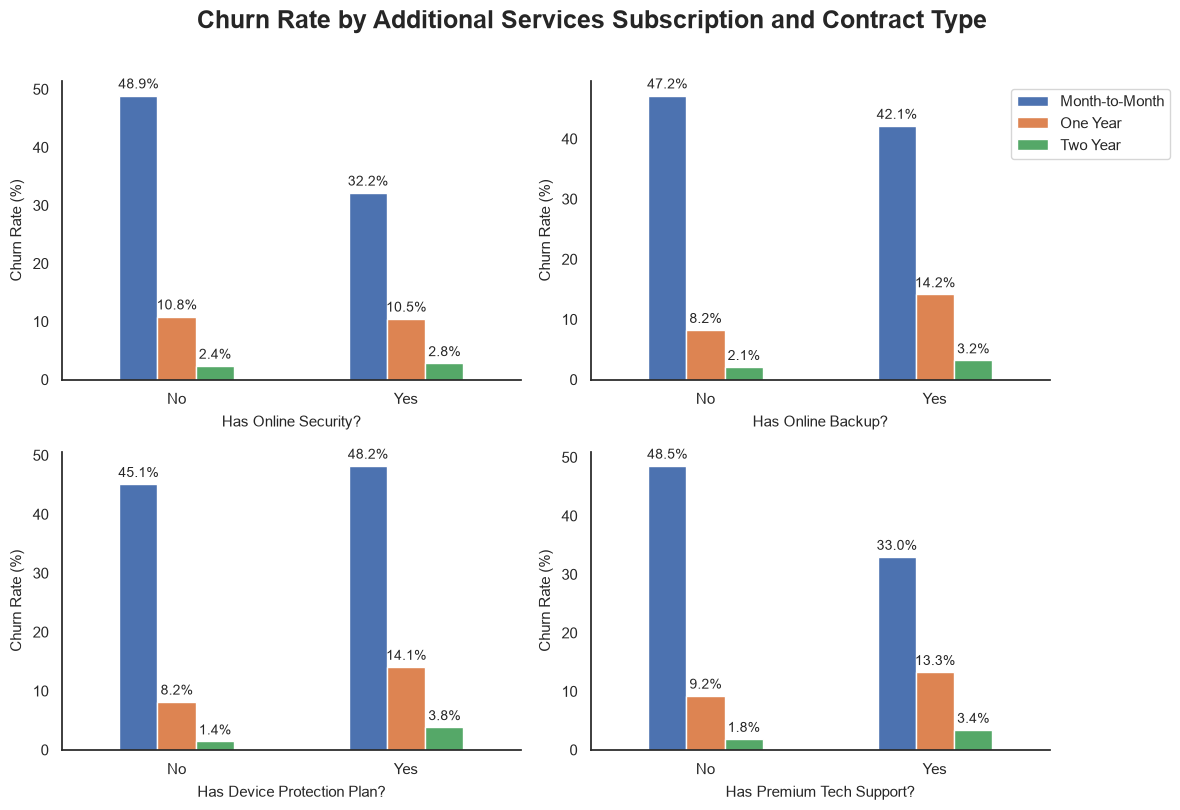

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax1, ax2, ax3, ax4 = axes.flatten()

churn_rate_by_security_contract.plot.bar(
    ax=ax1,
    legend=False
)

churn_rate_by_backup_contract.plot.bar(
    ax=ax2,
    legend=False
)

churn_rate_by_protection_contract.plot.bar(
    ax=ax3,
    legend=False
)

churn_rate_by_support_contract.plot.bar(
    ax=ax4,
    legend=False
)

for ax in axes.flatten():
    ax.set_xticks([0, 1], labels=['No', 'Yes'], rotation=0)
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel(f'Has {ax.get_xlabel()}?')

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.1f%%',
            padding=3,
            fontsize=10
        )

ax2.legend(bbox_to_anchor=(0.9, 1))
plt.suptitle('Churn Rate by Additional Services Subscription and Contract Type', fontweight='bold', y=1.01, fontsize=18)
plt.tight_layout()


- Month-to-Month contracts represent the highest churn risk across all services regardless of whether they have add-on services or not.
- Customers on Two Year contracts consistently churn under 4% while One Year contracts hover around 8% to 14%.
- On online security, month-to-month subscribers churn drops sharply from 48.9% down to 32.2%, a similar pattern with Premium Tech Support. Both services appear to provide tangible customer retention value where risk is highest.
- Because churn increases when customers have Device Protection (and Backup on 1-year plans), check if these services have hidden pain points (e.g., poor claim resolution, slow app performance, or price-to-value dissatisfaction that triggers cancellations)
- Promote Security & Tech Support to Month-to-Month customers: Bundling or discounting these two services during sign-up could significantly lower the ~49% churn rate for non-contract users.

### Customer Profile, Tenure, and Churn
- Does the relationship between age and churn vary with customer tenure?
- Do household characteristics and tenure show different churn patterns?

In [17]:
age_bins = list(range(19, 85, 5))
age_labels = [f'{age}-{age+4}' for age in age_bins[:-1]]
age_labels[-1] = '79-80'

churn_df['Age Group'] = pd.cut(
    churn_df['Age'],
    bins=age_bins,
    labels=age_labels,
    right=False
)

churn_count_per_age_group = churn_df.groupby('Age Group')['Customer Status'].value_counts()[:,'Churned']

churn_rate_per_age_group = (
    (churn_df.groupby('Age Group')['Customer Status'].value_counts()[:,'Churned']) /
    (churn_df['Age Group'].value_counts().sort_index()) * 100
)

churn_rate_by_age_tenure = (
    churn_df.groupby(['Tenure Group', 'Age Group'])['Customer Status']
     .value_counts()[:, :, 'Churned'] /
    churn_df.groupby(['Tenure Group', 'Age Group'])['Customer Status']
     .count()
    * 100
).unstack()

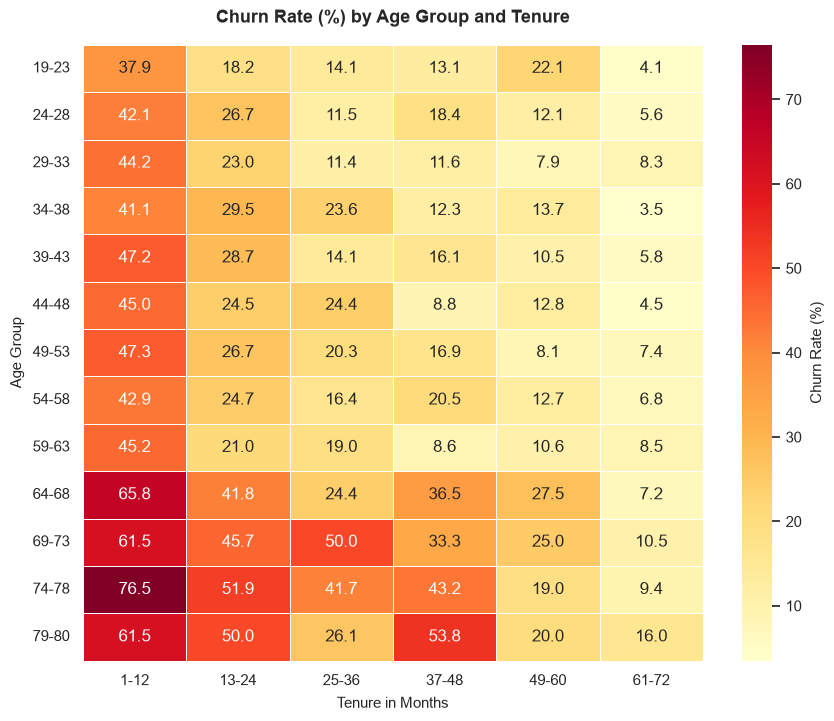

In [41]:
fig, ax = plt.subplots(figsize=(10, 8))
# If churn_rate_by_age_tenure has Tenure as index and Age Group as columns, transpose it (.T)
# so Age Group is on the y-axis and Tenure flows left-to-right on the x-axis
sns.heatmap(
    churn_rate_by_age_tenure.T,  
    cmap='YlOrRd',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': 'Churn Rate (%)'},
    ax=ax
)

ax.set_title('Churn Rate (%) by Age Group and Tenure')
ax.set_xlabel('Tenure in Months')
ax.set_ylabel('Age Group')
ax.tick_params(axis='y', rotation=0)

plt.show();

### Offers, Tenure, and Churn
- How does churn vary across offers at different tenure levels?
- Are differences in churn across offers partly associated with the tenure profiles of customers receiving those offers?